## Subsample Plot & Result

### Import and Path Setting

In [ ]:
import json
import time
import traceback
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import torch
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

from benchmark.config import (
    DATA_PROCESSED,
    RANDOM_STATE,
    RESULTS,
    RESULTS_BENCHMARK,
    TEST_SIZE,
)

# xRFM helpers
from benchmark.models.xrfm_model import make_processor, build_categorical_info

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from xrfm import xRFM

# XGBoost helpers (shared model module)
from benchmark.models.xgboost_model import (
    build_preprocessor as build_xgb_preprocessor,
    build_pipeline_clf as build_xgb_pipeline_clf,
)

# TabNet helpers (shared model module)
from tabpfn import TabPFNClassifier

# Random Forest helpers (shared model module)
from benchmark.models.random_forest_model import build_model as build_rf_model

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

/home/shado/college_project/comp9417/9417GroupProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Path
SUBSAMPLE_DIR = DATA_PROCESSED / "subsampled_sleep_health"
RESULTS_DIR = RESULTS / "04_learning_curve"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Where the per-model optimal-hyperparameter JSONs live
HPARAM_DIR = RESULTS_BENCHMARK / "sleep_health"

SUBSAMPLE_SIZES = [500, 1000, 2000, 4000, 6000, 8000, 12000, 16000]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device       : {DEVICE}")
print(f"Subsample dir: {SUBSAMPLE_DIR}")
print(f"Results dir  : {RESULTS_DIR}")

Device       : cuda
Subsample dir: /home/shado/college_project/comp9417/9417GroupProject/data/processed/subsampled_sleep_health
Results dir  : /home/shado/college_project/comp9417/9417GroupProject/results/04_learning_curve


In [3]:
# Metadata & test data
with open(SUBSAMPLE_DIR / "metadata.json") as f:
    metadata = json.load(f)

TARGET_COL = metadata["target_col"]
NUM_COLS = metadata["num_cols"]
CAT_COLS = metadata["cat_cols"]
BIN_COLS = metadata["bin_cols"]

test_df = pd.read_csv(SUBSAMPLE_DIR / "test.csv")
print(f"Test set size: {len(test_df)}")
print(f"Target       : {TARGET_COL}")

# Shared label encoder (fitted on test set classes – same across all splits)
le = LabelEncoder()
le.fit(test_df[TARGET_COL])
n_classes = len(le.classes_)
print(f"Classes ({n_classes}): {list(le.classes_)}")

# all results
all_results: dict[str, dict] = {}

Test set size: 4000
Target       : sleep_disorder_risk
Classes (4): ['Healthy', 'Mild', 'Moderate', 'Severe']


### Helper Function

In [4]:
def load_subsample(n: int) -> pd.DataFrame:
    """Load the subsampled training CSV for size *n*."""
    path = SUBSAMPLE_DIR / f"{n}sub_train.csv"
    return pd.read_csv(path)


def compute_metrics(y_true: np.ndarray, y_proba: np.ndarray) -> dict:
    """Return accuracy and macro AUC-ROC from integer labels + proba matrix."""
    y_pred = np.argmax(y_proba, axis=1)
    acc = accuracy_score(y_true, y_pred)
    if y_proba.shape[1] == 2:
        auc = roc_auc_score(y_true, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    return {"test_acc": float(acc), "test_auc_roc": float(auc)}


def plot_learning_curves(
    all_results: dict,
    metric_key: str,
    ylabel: str,
    title: str,
    save_path: Path,
) -> None:
    """Plot one learning-curve chart for a single metric across models."""
    fig, ax = plt.subplots(figsize=(9, 5))
    palette = sns.color_palette("deep", n_colors=len(all_results))
    for i, (model_name, size_dict) in enumerate(all_results.items()):
        sizes = sorted(int(k) for k in size_dict)
        values = [size_dict[str(s)][metric_key] for s in sizes]
        ax.plot(
            sizes, values, marker="o", linewidth=2, color=palette[i], label=model_name
        )
    ax.set_xlabel("Training subsample size", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=11)
    ax.set_xticks(SUBSAMPLE_SIZES)
    ax.set_xticklabels([str(s) for s in SUBSAMPLE_SIZES], rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

### xRFM

In [5]:
try:
    # Load best hyperparameters (nested format from sleep_health_xrfm.py)
    with open(HPARAM_DIR / "xrfm.json") as f:
        xrfm_hparams = json.load(f)
    best_params = xrfm_hparams["best_params"]
    print(f"Best params: {best_params}")

    # Extract tuned hyperparameters from the nested JSON structure.
    # Auto-set params (tuning_metric, split_method, bandwidth_mode,
    # verbose, early_stop_rfm) are hardcoded by the algorithm, not tuned.
    rfm_params = {
        "model": best_params["model"],
        "fit": best_params["fit"],
    }
    max_leaf_size = best_params["max_leaf_size"]
    n_num_cols = len(NUM_COLS)

    xrfm_results: dict[str, dict] = {}

    for n in SUBSAMPLE_SIZES:
        print(f"  n={n:>5} ... ", end="", flush=True)
        sub_df = load_subsample(n)

        X_sub = sub_df.drop(columns=TARGET_COL)
        y_sub = le.transform(sub_df[TARGET_COL]).astype(np.int32)

        # Internal train/val split (same as fit_best_xrfm in xrfm_model.py)
        X_train, X_val, y_train, y_val = train_test_split(
            X_sub,
            y_sub,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
        )

        # Preprocessing
        processor = make_processor(metadata)
        pipeline = Pipeline(steps=[("processor", clone(processor))])
        X_train_t = pipeline.fit_transform(X_train)
        X_val_t = pipeline.transform(X_val)

        # Categorical feature info for xRFM
        cat_info = (
            build_categorical_info(pipeline, n_num_cols)
            if n_num_cols < X_train_t.shape[1]
            else None
        )

        # Construct and fit xRFM directly
        model = xRFM(
            rfm_params=rfm_params,
            device=DEVICE,
            tuning_metric="f1",
            split_method="top_vector_agop_on_subset",
            categorical_info=cat_info,
            max_leaf_size=max_leaf_size,
        )
        t0 = time.perf_counter()
        model.fit(X_train_t, y_train, X_val_t, y_val)
        fit_time = time.perf_counter() - t0

        # Predict on test set
        X_test = test_df.drop(columns=TARGET_COL)
        y_test = le.transform(test_df[TARGET_COL]).astype(np.int32)
        X_test_t = pipeline.transform(X_test)
        y_proba = model.predict_proba(X_test_t)

        metrics = compute_metrics(y_test, y_proba)
        metrics["fit_time_s"] = float(fit_time)
        metrics["fit_time_persample_s"] = float(fit_time / n)
        xrfm_results[str(n)] = metrics
        print(
            f"acc={metrics['test_acc']:.4f}  auc={metrics['test_auc_roc']:.4f}  "
            f"fit={fit_time:.2f}s"
        )

    all_results["xRFM"] = xrfm_results
    print("xRFM done.\n")

except Exception as e:
    print(f"\n  [SKIP] xRFM failed: {e}")
    traceback.print_exc()

Best params: {'tuning_metric': 'f1', 'split_method': 'top_vector_agop_on_subset', 'max_leaf_size': 1648, 'model': {'bandwidth': 152.11384833667154, 'exponent': 1.295003121378433, 'diag': True, 'bandwidth_mode': 'constant', 'kernel': 'lpq', 'norm_p': 1.4694861792770701}, 'fit': {'reg': 2.248026232782218e-06, 'iters': 4, 'verbose': False, 'early_stop_rfm': True}}
  n=  500 ... None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 400, d: 70, and nval: 100
Using expensive batch size
Optimal M batch size: 400


Building trees:   0%|          | 0/1 [00:01<?, ?it/s]

Time taken for round 0: 1.0900702476501465 seconds
Using expensive batch size
Optimal M batch size: 400
Time taken for round 1: 0.008746147155761719 seconds
Using expensive batch size
Optimal M batch size: 400
Time taken for round 2: 0.008320331573486328 seconds
Using expensive batch size
Optimal M batch size: 400
Time taken for round 3: 0.007779598236083984 seconds
Tree has no split, stopping training
Using hard routing for tree prediction
acc=0.7350  auc=0.8786  fit=1.19s
  n= 1000 ... 

...

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([12160, 70]) y_train torch.Size([12160, 4]) X_val torch.Size([640, 70]) y_val torch.Size([640, 4])
Fitting RFM with ntrain: 12160, d: 70, and nval: 640
Using cheap batch size
Optimal M batch size: 2659
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([7296, 70]) y_train torch.Size([7296, 4]) X_val torch.Size([384, 70]) y_val torch.Size([384, 4])
Fitting RFM with ntrain: 7296, d: 70, and nval: 384
Using cheap batch size
Optimal M batch size: 2658
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([4377, 70]) y_train torch.Size([4377, 4]) X_val torch.Size([231, 70]) y_val torch.Size([231, 4])
Fitting RFM with ntrain: 4377, d: 70, and nval: 231
Using cheap batch size
Optimal M batch size: 2658
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([2626, 70]) y_train torch.Size([2626, 4]) X_val torc

Building trees: 100%|██████████| 1/1 [00:03<00:00,  3.33s/it]


Using expensive batch size
Optimal M batch size: 478
Time taken for round 0: 0.007982969284057617 seconds
Using expensive batch size
Optimal M batch size: 478
Time taken for round 1: 0.007801532745361328 seconds
Using expensive batch size
Optimal M batch size: 478
Time taken for round 2: 0.008283615112304688 seconds
Using expensive batch size
Optimal M batch size: 478
Time taken for round 3: 0.0074503421783447266 seconds
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 478, d: 70, and nval: 193
Using expensive batch size
Optimal M batch size: 478
Time taken for round 0: 0.0076007843017578125 seconds
Using expensive batch size
Optimal M batch size: 478
Time taken for round 1: 0.0074651241302490234 seconds
Using expensive batch size
Optimal M batch size: 478
Time taken for round 2: 0.007683515548706055 seconds
Using expensive batch size
Optimal M batch size: 478
Time taken for round 3: 0.008388519287109375 seconds


Tuning split temperature: 100%|██████████| 36/36 [00:02<00:00, 14.07it/s]

Selected split_temperature=0.182074901698571 based on validation f1=0.798888
Using soft routing for tree prediction
acc=0.9000  auc=0.9796  fit=5.90s
xRFM done.



### XGBoost

In [6]:
try:
    # Load best hyperparameters
    with open(HPARAM_DIR / "xgboost.json") as f:
        xgb_hparams = json.load(f)
    best_params = xgb_hparams["best_params"]
    print(f"Best params: {best_params}")

    # Add "model" prefix so pipeline.set_params() can route them
    best_search_params = {f"model__{k}": v for k, v in best_params.items()}

    xgb_device = "cuda" if torch.cuda.is_available() else "cpu"
    xgb_results: dict[str, dict] = {}

    for n in SUBSAMPLE_SIZES:
        print(f"  n={n:>5} ... ", end="", flush=True)
        sub_df = load_subsample(n)

        X_train = sub_df.drop(columns=TARGET_COL)
        y_train = le.transform(sub_df[TARGET_COL]).astype(np.int32)
        X_test = test_df.drop(columns=TARGET_COL)
        y_test = le.transform(test_df[TARGET_COL]).astype(np.int32)

        # Use shared helpers from xgboost_model.py
        preprocessor = build_xgb_preprocessor(metadata)
        pipe = build_xgb_pipeline_clf(
            preprocessor,
            n_classes,
            device=xgb_device,
            n_jobs=-1,
        )
        pipe.set_params(**best_search_params)

        t0 = time.perf_counter()
        pipe.fit(X_train, y_train)
        fit_time = time.perf_counter() - t0

        y_proba = pipe.predict_proba(X_test)
        metrics = compute_metrics(y_test, y_proba)
        metrics["fit_time_s"] = float(fit_time)
        metrics["fit_time_persample_s"] = float(fit_time / n)
        xgb_results[str(n)] = metrics
        print(
            f"acc={metrics['test_acc']:.4f}  auc={metrics['test_auc_roc']:.4f}  "
            f"fit={fit_time:.2f}s"
        )

    all_results["XGBoost"] = xgb_results
    print("XGBoost done.\n")

except Exception as e:
    print(f"\n  [SKIP] XGBoost failed: {e}")
    traceback.print_exc()

Best params: {'n_estimators': 725, 'learning_rate': 0.13565773665802744, 'max_depth': 3, 'min_child_weight': 6, 'subsample': 0.7922903329492129, 'colsample_bytree': 0.8504326788691458, 'gamma': 0.21905332579218617, 'reg_alpha': 0.002441592339653542, 'reg_lambda': 3.5048149824176797}
  n=  500 ... acc=0.7900  auc=0.9270  fit=2.00s
  n= 1000 ... acc=0.8253  auc=0.9473  fit=2.18s
  n= 2000 ... acc=0.8835  auc=0.9688  fit=2.59s
  n= 4000 ... acc=0.9093  auc=0.9790  fit=2.83s
  n= 6000 ... acc=0.9247  auc=0.9844  fit=3.04s
  n= 8000 ... acc=0.9347  auc=0.9859  fit=3.20s
  n=12000 ... acc=0.9465  auc=0.9900  fit=3.23s
  n=16000 ... acc=0.9477  auc=0.9908  fit=3.23s
XGBoost done.



### TabPFN

In [ ]:
try:
    # Load best hyperparameters
    with open(HPARAM_DIR / "tabpfn.json") as f:
        tabpfn_hparams = json.load(f)
    tabpfn_params = tabpfn_hparams.get("tabpfn_params", {})
    n_estimators = tabpfn_params.get("n_estimators", 2)
    print(f"TabPFN params: n_estimators={n_estimators}")

    # Feature columns in the order: num, cat, bin
    feature_cols = NUM_COLS + CAT_COLS + BIN_COLS
    if len(NUM_COLS) < len(feature_cols):
        cat_indices = list(range(len(NUM_COLS), len(feature_cols)))
    else:
        cat_indices = None

    tabpfn_results: dict[str, dict] = {}

    for n in SUBSAMPLE_SIZES:
        print(f"  n={n:>5} ... ", end="", flush=True)
        sub_df = load_subsample(n)

        X_train = sub_df[feature_cols].copy()
        y_train = le.transform(sub_df[TARGET_COL]).astype(np.int32)
        X_test = test_df[feature_cols].copy()
        y_test = le.transform(test_df[TARGET_COL]).astype(np.int32)

        clf = TabPFNClassifier(
            categorical_features_indices=cat_indices,
            device="auto",
            ignore_pretraining_limits=True,
            random_state=RANDOM_STATE,
            n_estimators=n_estimators,
        )

        t0 = time.perf_counter()
        clf.fit(X_train, y_train)
        fit_time = time.perf_counter() - t0

        y_proba = clf.predict_proba(X_test)
        metrics = compute_metrics(y_test, y_proba)
        metrics["fit_time_s"] = float(fit_time)
        metrics["fit_time_persample_s"] = float(fit_time / n)
        tabpfn_results[str(n)] = metrics
        print(
            f"acc={metrics['test_acc']:.4f}  auc={metrics['test_auc_roc']:.4f}  "
            f"fit={fit_time:.2f}s"
        )

    all_results["TabPFN"] = tabpfn_results
    print("TabPFN done.\n")

except Exception as e:
    print(f"\n  [SKIP] TabPFN failed: {e}")
    traceback.print_exc()

TabPFN params: n_estimators=8
  n=  500 ... 
  [SKIP] TabPFN failed: TabPFNClassifier.__init__() got an unexpected keyword argument 'device'


Traceback (most recent call last):
  File "/tmp/ipykernel_91942/2806359789.py", line 27, in <module>
    clf = TabPFNClassifier(
        device="auto",
    ...<2 lines>...
        n_estimators=n_estimators,
    )
TypeError: TabPFNClassifier.__init__() got an unexpected keyword argument 'device'


### Random Forest

In [8]:
try:
    rf_json_path = HPARAM_DIR / "random_forest.json"
    if not rf_json_path.exists():
        raise FileNotFoundError(
            f"{rf_json_path} not found – Random Forest will be skipped."
        )

    with open(rf_json_path) as f:
        rf_hparams = json.load(f)
    best_params = rf_hparams["best_params"]
    print(f"Best params: {best_params}")

    # Add fixed params matching random_forest_model.py conventions
    rf_params = {
        **best_params,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    # Preprocessor matching rf_sleep_health.py
    def build_rf_preprocessor():
        return ColumnTransformer(
            transformers=[
                ("num", "passthrough", NUM_COLS),
                ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS),
                ("bin", OrdinalEncoder(), BIN_COLS),
            ],
            remainder="passthrough",
        )

    rf_results: dict[str, dict] = {}

    for n in SUBSAMPLE_SIZES:
        print(f"  n={n:>5} ... ", end="", flush=True)
        sub_df = load_subsample(n)

        X_train = sub_df.drop(columns=TARGET_COL)
        y_train = le.transform(sub_df[TARGET_COL]).astype(np.int32)
        X_test = test_df.drop(columns=TARGET_COL)
        y_test = le.transform(test_df[TARGET_COL]).astype(np.int32)

        # Use build_model helper from random_forest_model.py
        rf_model = build_rf_model(task="classification", rf_params=rf_params)
        preprocessor = build_rf_preprocessor()
        pipe = Pipeline([("processor", preprocessor), ("model", rf_model)])

        t0 = time.perf_counter()
        pipe.fit(X_train, y_train)
        fit_time = time.perf_counter() - t0

        y_proba = pipe.predict_proba(X_test)
        metrics = compute_metrics(y_test, y_proba)
        metrics["fit_time_s"] = float(fit_time)
        metrics["fit_time_persample_s"] = float(fit_time / n)
        rf_results[str(n)] = metrics
        print(
            f"acc={metrics['test_acc']:.4f}  auc={metrics['test_auc_roc']:.4f}  "
            f"fit={fit_time:.2f}s"
        )

    all_results["Random Forest"] = rf_results
    print("Random Forest done.\n")

except Exception as e:
    print(f"\n  [SKIP] Random Forest failed: {e}")
    traceback.print_exc()

Best params: {'n_estimators': 82, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}
  n=  500 ... acc=0.7448  auc=0.9179  fit=0.09s
  n= 1000 ... acc=0.7805  auc=0.9329  fit=0.08s
  n= 2000 ... acc=0.8073  auc=0.9492  fit=0.10s
  n= 4000 ... acc=0.8240  auc=0.9563  fit=0.10s
  n= 6000 ... acc=0.8357  auc=0.9618  fit=0.12s
  n= 8000 ... acc=0.8458  auc=0.9642  fit=0.13s
  n=12000 ... acc=0.8445  auc=0.9671  fit=0.14s
  n=16000 ... acc=0.8572  auc=0.9695  fit=0.17s
Random Forest done.



### Result

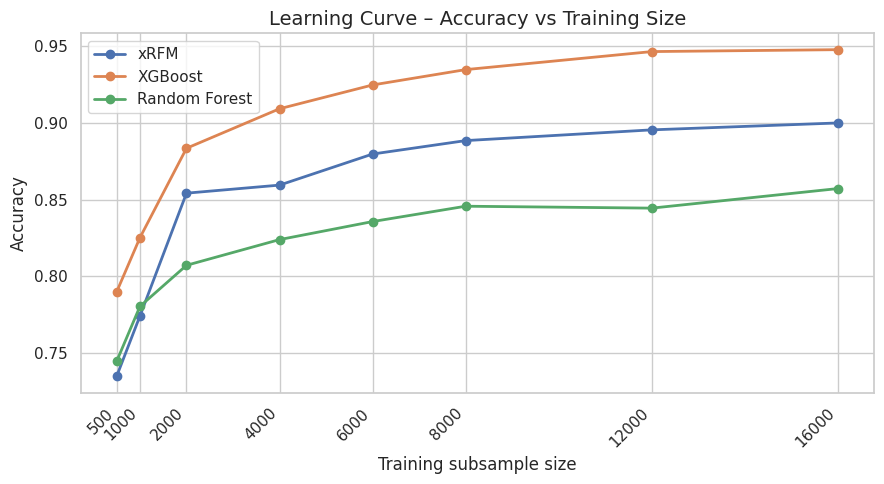

Saved: /home/shado/college_project/comp9417/9417GroupProject/results/04_learning_curve/learning_curve_sleep_health_accuracy.png


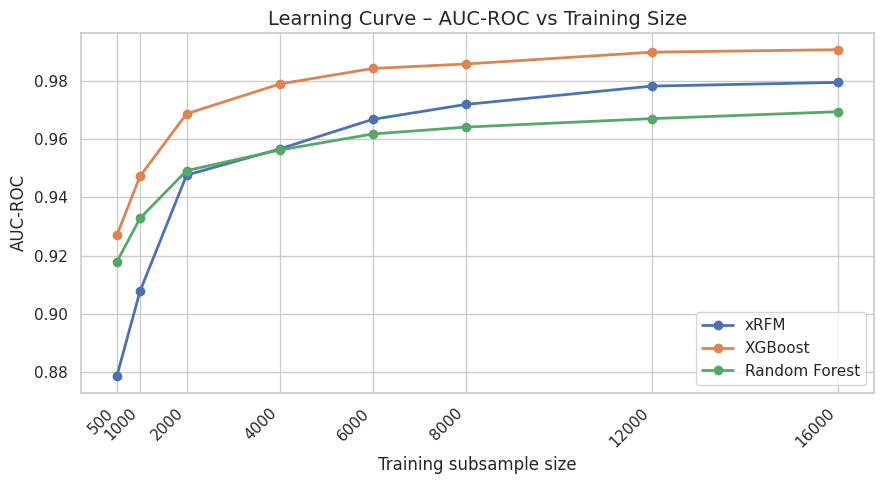

Saved: /home/shado/college_project/comp9417/9417GroupProject/results/04_learning_curve/learning_curve_sleep_health_auc_roc.png


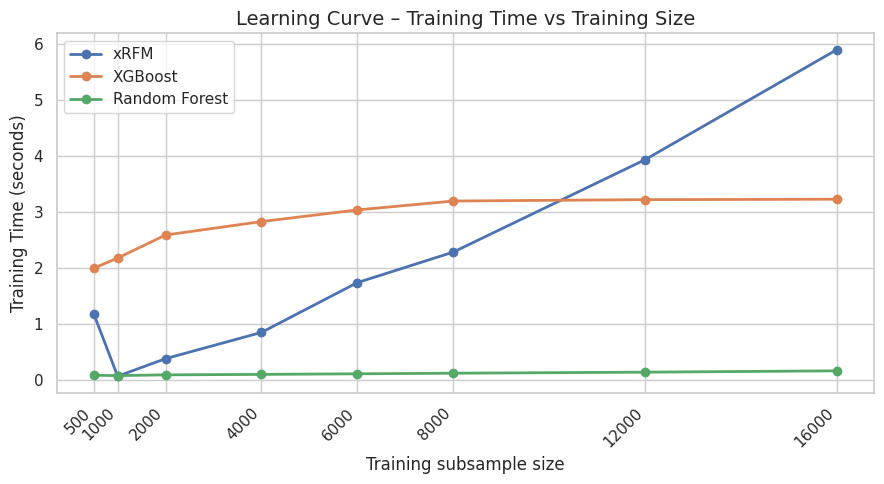

Saved: /home/shado/college_project/comp9417/9417GroupProject/results/04_learning_curve/learning_curve_sleep_health_fit_time.png


In [9]:
# Plot
plot_learning_curves(
    all_results,
    metric_key="test_acc",
    ylabel="Accuracy",
    title="Learning Curve – Accuracy vs Training Size",
    save_path=RESULTS_DIR / "learning_curve_sleep_health_accuracy.png",
)

plot_learning_curves(
    all_results,
    metric_key="test_auc_roc",
    ylabel="AUC-ROC",
    title="Learning Curve – AUC-ROC vs Training Size",
    save_path=RESULTS_DIR / "learning_curve_sleep_health_auc_roc.png",
)

plot_learning_curves(
    all_results,
    metric_key="fit_time_s",
    ylabel="Training Time (seconds)",
    title="Learning Curve – Training Time vs Training Size",
    save_path=RESULTS_DIR / "learning_curve_sleep_health_fit_time.png",
)

In [10]:
# Json
json_path = RESULTS_DIR / "learning_curve_sleep_health.json"
with open(json_path, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"\nResults JSON saved to {json_path}")
print(f"Models included: {list(all_results.keys())}")


Results JSON saved to /home/shado/college_project/comp9417/9417GroupProject/results/04_learning_curve/learning_curve_sleep_health.json
Models included: ['xRFM', 'XGBoost', 'Random Forest']
